In [1]:
import os
# Workaround for Mac M1 OpenMP conflict when loading torch
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import pytorch_lightning as pl
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.distributions import NegativeBinomial

from footprinting import get_count_matrix, get_bw_signal, plot_count_matrix

# Dataset
class FootprintDataset(Dataset):
    def __init__(self, regions, accessor_fn):
        """
        regions: list of (chrom, start, end) tuples
        accessor_fn: function(chrom, start, end) -> (footprint, total_signal, procap)
        footprint: np array (scales, length)
        total_signal: np array (length,)
        procap: np array (length,)
        """
        self.regions = regions
        self.accessor = accessor_fn

    def __len__(self):
        return len(self.regions)

    def __getitem__(self, idx):
        chrom, start, end = self.regions[idx]
        fp, total_signal, procap = self.accessor(chrom, start, end)
        x_fp = torch.from_numpy(fp).float().unsqueeze(1)      # (scales, 1, length)
        x_signal = torch.from_numpy(total_signal).float().unsqueeze(0).unsqueeze(2)  # (1, length) -> (1,1,length)
        x = torch.cat([x_fp, x_signal], dim=0)  # (channels, 1, length)
        y = torch.from_numpy(procap).float()  # (length,)
        return x, y

# DataModule
class FootprintDataModule(pl.LightningDataModule):
    def __init__(self, train_regions, val_regions, accessor_fn,
                 batch_size=16, num_workers=4):
        super().__init__()
        self.train_regions = train_regions
        self.val_regions = val_regions
        self.accessor_fn = accessor_fn
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.train_ds = FootprintDataset(self.train_regions, self.accessor_fn)
        self.val_ds   = FootprintDataset(self.val_regions,   self.accessor_fn)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True,
                          num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False,
                          num_workers=self.num_workers, pin_memory=True)

# U-Net with global context
class UNetLightning(pl.LightningModule):
    def __init__(self, in_channels, base_filters=32, embed_dim=32,
                 lr=1e-3, weight_decay=1e-5):
        super().__init__()
        self.save_hyperparameters()
        # Encoder
        self.enc1 = self._conv_block(in_channels, base_filters)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self._conv_block(base_filters, base_filters*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self._conv_block(base_filters*2, base_filters*4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self._conv_block(base_filters*4, base_filters*8)
        self.pool4 = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_filters*8, base_filters*16, kernel_size=3, padding=2, dilation=2),
            nn.BatchNorm2d(base_filters*16),
            nn.ReLU(),
            nn.Conv2d(base_filters*16, base_filters*16, kernel_size=3, padding=2, dilation=2),
            nn.BatchNorm2d(base_filters*16),
            nn.ReLU(),
        )
        # Global-context branch
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(base_filters*16, base_filters*4),
            nn.ReLU(),
            nn.Linear(base_filters*4, embed_dim),
        )
        # Decoder + skip connections
        self.up4 = nn.ConvTranspose2d(base_filters*16 + embed_dim, base_filters*8, 2, 2)
        self.dec4 = self._conv_block(base_filters*8*2 + embed_dim, base_filters*8)
        self.up3 = nn.ConvTranspose2d(base_filters*8 + embed_dim, base_filters*4, 2, 2)
        self.dec3 = self._conv_block(base_filters*4*2 + embed_dim, base_filters*4)
        self.up2 = nn.ConvTranspose2d(base_filters*4 + embed_dim, base_filters*2, 2, 2)
        self.dec2 = self._conv_block(base_filters*2*2 + embed_dim, base_filters*2)
        self.up1 = nn.ConvTranspose2d(base_filters*2 + embed_dim, base_filters, 2, 2)
        self.dec1 = self._conv_block(base_filters*2 + embed_dim, base_filters)
        # Output heads
        self.conv_mu = nn.Conv2d(base_filters, 1, kernel_size=1)
        self.theta = nn.Parameter(torch.ones(1) * 5.0)
        self.lr = lr
        self.weight_decay = weight_decay

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        bn = self.bottleneck(p4)
        # Global context
        g = self.global_pool(bn).view(bn.size(0), -1)
        emb = self.mlp(g)
        # Decoder
        merged = torch.cat([bn, emb[:,:,None,None].expand(-1,-1,bn.size(2),bn.size(3))], dim=1)
        d4 = self.up4(merged)
        cat4 = torch.cat([d4, e4, emb[:,:,None,None].expand(-1,-1,e4.size(2),e4.size(3))], dim=1)
        d4 = self.dec4(cat4)
        # Continue pyramid for d3, d2, d1...
        # Output
        mu_map = nn.functional.softplus(self.conv_mu(d1)).squeeze(1)
        mu = mu_map.mean(dim=1)
        theta = nn.functional.softplus(self.theta)
        return mu, theta

    def training_step(self, batch, batch_idx):
        x, y = batch
        mu, theta = self(x)
        probs = theta / (theta + mu)
        nb = NegativeBinomial(total_count=theta, probs=probs)
        loss = -nb.log_prob(y).mean()
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        mu, theta = self(x)
        probs = theta / (theta + mu)
        nb = NegativeBinomial(total_count=theta, probs=probs)
        loss = -nb.log_prob(y).mean()
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)



In [ ]:
def get_footprint_and_procap(fragment_counts_gz, 
                             procap_bw, 
                             chrom, window_start, window_end, footprint_sigma=10):
    footprint = get_count_matrix(counts_gz = fragment_counts_gz, 
                                 chrom=chrom, window_start=window_start, window_end=window_end, 
                                 sigma=footprint_sigma)
    
    # Calculate 99th percentile of the footprint signal < 80bp
    mean_short_footprint_signal =  footprint.loc[footprint.index < 80].mean().mean()

    procap = get_bw_signal(procap_bw, chrom, 80_000_000, 80_003_000)

    return footprint, mean_short_footprint_signal, procap


(141, 1001) 0.023142054254754598 (3000,)


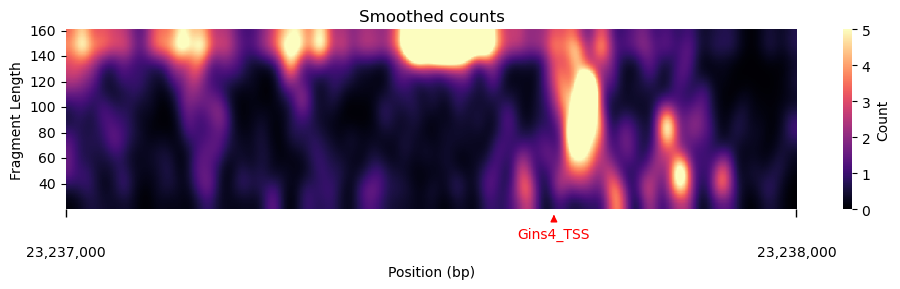

In [16]:
### TEMP
 
counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'
chrom = 'chr8'

footprint, mean_short_footprint_signal, procap = \
    get_footprint_and_procap(fragment_counts_gz=counts_gz, 
                                procap_bw=procap_bw,
                                chrom=chrom, window_start=23_237_000, window_end=23_238_000, footprint_sigma=10)
    # Normalize footprint by mean signal of <80bp fragments 

footprint = footprint / mean_short_footprint_signal

print(footprint.shape, mean_short_footprint_signal, procap.shape)
    

# Gins4 chr8:23226610-23237668 (-)
markers = {
    23_237_668: 'Gins4_TSS',
    #23_237_650: 'PRO-Cap peak',
}

plot_count_matrix(footprint, vmax = 5, named_positions=markers, 
                  title='Smoothed counts')



In [ ]:
counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'
chrom = 'chr8'


train_regions = [("chr1", 100, 200), ("chr1", 300, 400)]  # list of (chrom, start, end)
val_regions   = [...]  # list of (chrom, start, end)
from your_accessors import get_footprint_and_procap

dm = FootprintDataModule(train_regions, val_regions, get_footprint_and_procap)
model = UNetLightning(in_channels=101)  # 100 scales + 1 total_signal channel
trainer = pl.Trainer(gpus=1, precision=16, max_epochs=50, gradient_clip_val=1.0)
trainer.fit(model, dm)